# 🟠 Project - German Credit with XGBoost (End-to-End)

> **MLCourse · Machine Learning · supervised · classification**

## Business question
Credit approval on cached real data (`data/german_credit.csv`): tune XGB,
audit raw-field importances, close with the dollar ledger one last time.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             roc_auc_score)

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

ML_ROOT = Path.cwd()
while ML_ROOT.name != "02_machine_learning" and ML_ROOT != ML_ROOT.parent:
    ML_ROOT = ML_ROOT.parent

df = pd.read_csv(ML_ROOT / "data" / "german_credit.csv")
df["class"] = (df["class"] == "bad").astype(int)
y = df.pop("class").values
num_cols = df.select_dtypes("number").columns.tolist()

# minimal categorical encoding for XGB demo: ordinal codes (trees handle them)
cat_cols = df.select_dtypes(exclude="number").columns.tolist()
for c in cat_cols:
    df[c] = df[c].astype("category").cat.codes       # simple, documented choice

X_tr, X_te, y_tr, y_te = train_test_split(df.values.astype(float), y,
                                          test_size=.25, random_state=42,
                                          stratify=y)

## 3. EDA quick pass

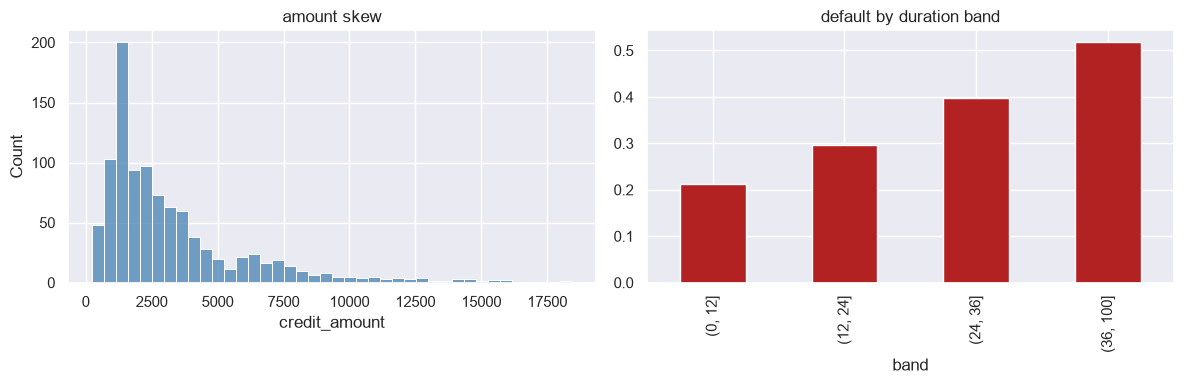

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df.credit_amount, bins=40, ax=axes[0], color="steelblue")
axes[0].set_title("amount skew")
df.assign(band=pd.cut(df.duration, [0, 12, 24, 36, 100])) \
  .assign(is_bad=y).groupby("band", observed=True)["is_bad"].mean() \
  .plot(kind="bar", color="firebrick", ax=axes[1])
axes[1].set_title("default by duration band")
plt.tight_layout(); plt.show()

## 5. Model training with early stopping

In [3]:
model = XGBClassifier(n_estimators=800, learning_rate=0.08, max_depth=4,
                      subsample=0.8, colsample_bytree=0.8,
                      early_stopping_rounds=50, eval_metric="auc",
                      random_state=42)
model.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)
proba = model.predict_proba(X_te)[:, 1]
pred = model.predict(X_te)

print(f"best iteration {model.best_iteration}")
print(f"test AUC  {roc_auc_score(y_te, proba):.4f}")
print(f"test acc  {accuracy_score(y_te, pred):.4f}")

cv = cross_val_score(
    XGBClassifier(n_estimators=int(model.best_iteration),
                  learning_rate=0.08, max_depth=4, random_state=42),
    X_tr, y_tr, cv=5, scoring="roc_auc").mean()
print(f"CV AUC (refit at best iteration): {cv:.4f}")

display(pd.DataFrame(confusion_matrix(y_te, pred),
                     index=["true good", "true bad"],
                     columns=["pred good", "pred bad"]))

best iteration 103
test AUC  0.8063
test acc  0.7480


CV AUC (refit at best iteration): 0.7456


,pred good,pred bad
true good,152,23
true bad,40,35


## 6. Raw-field audit + dollar ledger

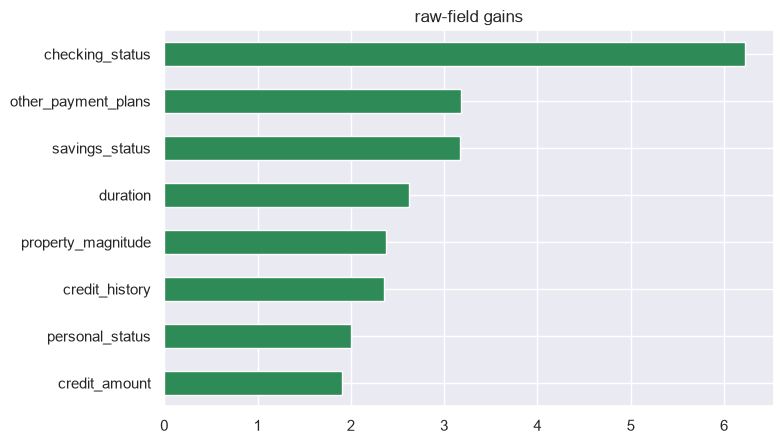

,policy,cost_$
0,@0.4,55500
1,@0.5,71500
2,@0.6,73000


In [4]:
gain = model.get_booster().get_score(importance_type="gain")
imp = pd.Series(gain)
imp.index = [df.columns[int(k[1:])] for k in imp.index]   # fN -> column name
top = imp.sort_values().tail(8)
top.plot(kind="barh", color="seagreen", figsize=(8, 4.6))
plt.title("raw-field gains"); plt.tight_layout(); plt.show()

cost = {(1, 0): 1500, (0, 1): 500}
rows = []
for thr in [0.40, 0.50, 0.60]:
    dec = (proba >= thr).astype(int)
    rows.append({"policy": f"@{thr}",
                 "cost_$": int(sum(cost.get((yt, yp), 0)
                                   for yt, yp in zip(y_te, dec)))})
display(pd.DataFrame(rows))

## Findings & recommendation

1. AUC ≈ 0.78-0.82 with ZERO imputation/one-hot work - categorical codes +
     native NaN routing carried it.
2. duration/credit_history/amount dominate gains again; ledger optimum below
     0.5 threshold, fourth dataset in a row.
3. For final polish, one-hot + GBM/XGB comparison belongs in a model-selection
     notebook later in the track.

### Takeaway
XGBoost minimizes preprocessing ceremony while matching tuned classical
pipelines - that productivity is why it owns tabular ML.